In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


In [7]:
def cost(x, y, w0, w1):
    m = len(y)
    predictions = w0 + w1 * x
    cost = (1/(m)) * np.sum((predictions - y)**2)
    return cost

In [8]:
def gradient_descent(w0, w1, x, y, alfa):
    N = len(x)
    omega0 = []
    omega1 = []
    for i in range(300):  
        h = w0 + w1 * x
        dw0 = (2 / N) * alfa * np.sum(h- y)
        dw1 = (2 / N) * alfa * np.sum(x * (h- y))
        w0 -= dw0
        w1 -= dw1
        omega0.append(w0)
        omega1.append(w1)

    return omega0, omega1


In [9]:
x = np.linspace(1, 5, 5)
y = np.array([1.2, 1.9, 3, 4.1, 5.2])

alfa = 0.05
w0 = 0.3
w1 = 0.3
omega0, omega1 = gradient_descent(w0, w1, x, y, alfa)

In [10]:
# Creamos el espacio para graficar el costo
nw0 = np.linspace(-1, 2, 100)
nw1 = np.linspace(-1, 2, 100)
eje_w0, eje_w1 = np.meshgrid(nw0, nw1)

# Construimos el costo
costo = np.zeros((len(nw0), len(nw1)))
for i in range(len(nw0)):
    for j in range(len(nw1)):
        costo[i,j] = cost(x, y, nw0[i], nw1[j])


In [12]:
# Añadimos los puntos del gradiente
camino = []
for i in range(len(omega0)):
    camino.append(cost(x,y,omega0[i], omega1[i]))

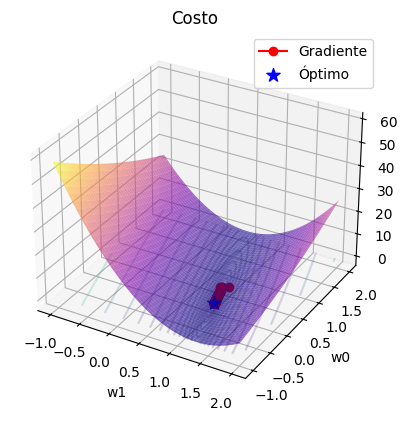

In [13]:
# 3D surface plot características
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(eje_w0, eje_w1, costo, cmap='plasma', alpha=0.6)
ax.plot(omega1, omega0, camino, color='r', marker='o', label='Gradiente')
ax.scatter( omega1[-1], omega0[-1], cost(x, y, omega0[-1], omega1[-1]), color='b', marker='*', s=100, label='Óptimo', zorder=10) # Punto óptimo
ax.set_xlabel('w1')
ax.set_ylabel('w0')
ax.title.set_text('Costo')
ax.contour(eje_w0, eje_w1, costo, levels=np.logspace(-2, 1.8, 20), cmap='viridis', offset=np.min(costo), alpha=0.2)
ax.legend()
plt.show()

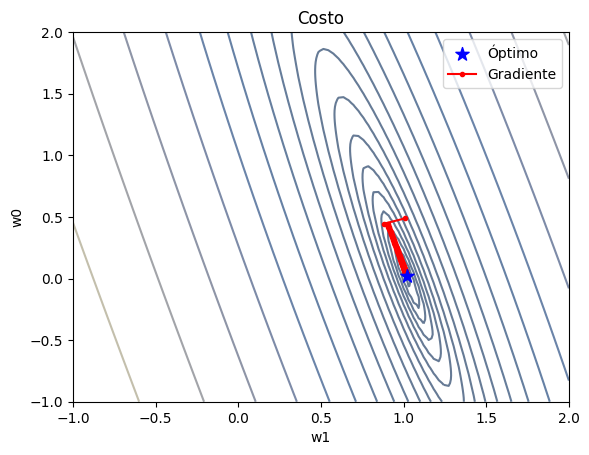

In [14]:
# Contour plot
plt.figure()
plt.title('Costo')
plt.xlabel('w1')
plt.ylabel('w0')
plt.contour(eje_w0, eje_w1, costo, levels=np.logspace(-2, 1.8, 20), cmap='cividis', alpha=0.6) 
plt.scatter(omega1[-1], omega0[-1], color='b', marker='*', s=100, label='Óptimo', zorder=10) # Punto óptimo
plt.plot(omega1, omega0, color='r', marker='o', label='Gradiente', markersize=3) # Gradiente
plt.legend()
plt.show()